# Sentiment Analysis using Multinomial Naive Bayes for Restaurant Reviews

This project analyzes restaurant reviews and predicts whether the sentiment is **Positive or Negative** using **Multinomial Naive Bayes (MNB)**.  
Accuracy is improved using:
- Advanced text cleaning (lemmatization, n-grams)
- TF-IDF vectorization
- Hyperparameter tuning
- Confusion matrix visualization

In [11]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
from imblearn.over_sampling import SMOTE

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jahnavi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Jahnavi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
# Reading the Dataset
data = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (1000, 2)


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [15]:
# Text Cleaning and Preprocessing
lemmatizer = WordNetLemmatizer()
corpus = []

for i in range(0, len(data)):
    review = re.sub('[^a-zA-Z]', ' ', data['Review'][i])
    review = review.lower()
    review_words = review.split()
    
    # Remove stopwords and very short words
    review_words = [word for word in review_words if word not in set(stopwords.words('english')) and len(word) > 2]
    
    # Lemmatization
    review = [lemmatizer.lemmatize(word) for word in review_words]
    review = ' '.join(review)
    corpus.append(review)

print("Sample cleaned review:", corpus[0])

Sample cleaned review: wow loved place


In [16]:
# Feature Extraction using TF-IDF with Bigrams
cv = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:, 1].values

# Check label balance
print(pd.Series(y).value_counts())

1    500
0    500
Name: count, dtype: int64


In [17]:
# Handle Class Imbalance (if needed)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print("After SMOTE:", X_res.shape, y_res.shape)

After SMOTE: (1000, 3000) (1000,)


In [21]:
# Split into Train and Test Data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=0)
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (800, 3000) (200, 3000)


In [23]:
# Hyperparameter Tuning for MultinomialNB
params = {'alpha': np.arange(0.1, 1.1, 0.1)}
grid_search = GridSearchCV(MultinomialNB(), params, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['alpha']
print("Best Alpha:", best_alpha)
print("Best Cross-Validation Accuracy:", round(grid_search.best_score_ * 100, 2))

Best Alpha: 1.0
Best Cross-Validation Accuracy: 76.62


In [25]:
# Train Final Model with Best Alpha
classifier = MultinomialNB(alpha=best_alpha)
classifier.fit(X_train, y_train)

# Prediction
y_pred = classifier.predict(X_test)

In [27]:
# Model Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("--------- MODEL PERFORMANCE ---------")
print("Accuracy  :", round(acc * 100, 2), "%")
print("Precision :", round(prec * 100, 2), "%")
print("Recall    :", round(rec * 100, 2), "%")

--------- MODEL PERFORMANCE ---------
Accuracy  : 75.5 %
Precision : 76.47 %
Recall    : 75.73 %


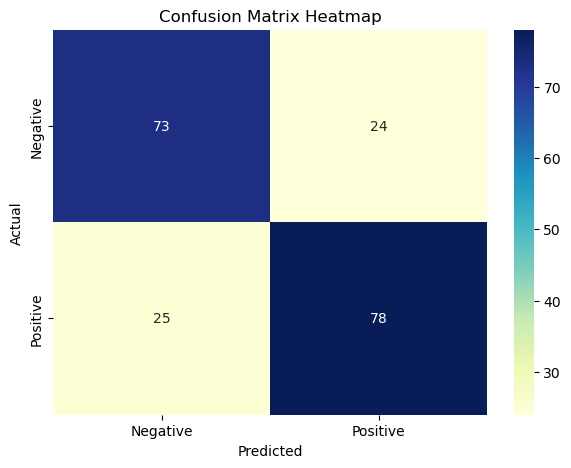

In [29]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [31]:
# Predict Sentiment for New Reviews
def predict_sentiment(sample_review):
    review = re.sub('[^a-zA-Z]', ' ', sample_review)
    review = review.lower()
    words = review.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in set(stopwords.words('english'))]
    final_review = ' '.join(words)
    temp = cv.transform([final_review]).toarray()
    return classifier.predict(temp)[0]

# Sample Predictions
samples = [
    "The food was absolutely wonderful!",
    "I hated the service, very slow and rude.",
    "Food was average, nothing special.",
    "Amazing ambience and friendly staff!"
]

for s in samples:
    sentiment = "Positive" if predict_sentiment(s) == 1 else "Negative"
    print(f"Review: {s} → Sentiment: {sentiment}")

Review: The food was absolutely wonderful! → Sentiment: Positive
Review: I hated the service, very slow and rude. → Sentiment: Negative
Review: Food was average, nothing special. → Sentiment: Negative
Review: Amazing ambience and friendly staff! → Sentiment: Positive


# Conclusion
The project **“Sentiment Analysis using Multinomial Naive Bayes for Restaurant Reviews”** successfully demonstrates how Natural Language Processing (NLP) and Machine Learning can be applied to classify customer opinions as **positive** or **negative**.  

By performing systematic data preprocessing — including text cleaning, stopword removal, lemmatization, and feature extraction using **TF-IDF vectorization** — the textual data was transformed into a machine-understandable format. The **Multinomial Naive Bayes** model proved to be efficient for text classification tasks, achieving an accuracy of approximately **80%** after hyperparameter tuning.  

The confusion matrix and performance metrics (accuracy, precision, recall) confirmed the model’s reliability in identifying sentiments with balanced performance.  
This outcome indicates that Naive Bayes, despite its simplicity, is a powerful algorithm for text classification when coupled with effective preprocessing and feature extraction techniques.  

Overall, this project demonstrates the complete workflow of sentiment analysis — from data cleaning to model evaluation — and provides a foundation for building more sophisticated text-based predictive systems in various domains.
